# Ablation Study

## 1. Setup, Imports, and Metric Tracking

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import tensorflow.keras as keras
from tensorflow.keras.layers import Input, Dense, Conv1D, Flatten, BatchNormalization, Dropout
from IPython.display import display, HTML

# Strict reproducibility to ensure peak performance
np.random.seed(42)
tf.random.set_seed(42)

# Dictionaries to store results
tcn_results = {}
ae_results = {}

def get_metrics(y_true, y_pred, y_prob):
    """Calculates standard classification metrics."""
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc = roc_auc_score(y_true, y_prob)
    return {'Accuracy': acc, 'Recall': rec, 'Specificity': spec, 'F1': f1, 'AUC': auc}

print("Libraries imported and environment initialized.")

E0000 00:00:1778428781.026676      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778428781.084293      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778428781.517556      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778428781.517595      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778428781.517599      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778428781.517601      57 computation_placer.cc:177] computation placer already registered. Please check linka

Libraries imported and environment initialized.


## 2. Data Loading and Dual Preprocessing (RF vs PCA)

In [2]:
# 1. Load Data
file_path = "/kaggle/input/datasets/subhajournal/trojan-detection/Trojan_Detection.csv" 
try:
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    df.drop(columns=['Unnamed: 0','Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Timestamp'], errors='ignore', inplace=True)
    df.dropna(inplace=True)
    df['Class'] = df['Class'].apply(lambda x: 0 if str(x).strip().upper() == 'BENIGN' else 1)
except Exception as e:
    print(f"Update file path! Using dummy data for compilation. Error: {e}")
    df = pd.DataFrame(np.random.rand(10000, 40), columns=[f'feature_{i}' for i in range(40)])
    df['Class'] = np.random.choice([0, 1], 10000)

target_col = 'Class'
X_raw = df.drop(columns=[target_col]).select_dtypes(include=[np.number])
y = df[target_col].values

# Base Scaling
X_log = np.log1p(X_raw.abs())
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_log)

# Preprocessing A: Proposed Tree-Based Selection
rf_selector = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_selector.fit(X_scaled, y)
top_indices = np.argsort(rf_selector.feature_importances_)[::-1][:30]
X_rf = X_scaled[:, top_indices]

# Preprocessing B: Ablated PCA
pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Data preprocessing complete (Proposed RF and Ablated PCA datasets generated).")

Data preprocessing complete (Proposed RF and Ablated PCA datasets generated).


## 3. Data Shaping (1D Flat vs 3D Sequences)

In [3]:
# Temporal Split (Prevents data leakage)
X_train_rf, X_test_rf, y_train, y_test = train_test_split(X_rf, y, test_size=0.2, shuffle=False)
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca, y, test_size=0.2, shuffle=False)

# Shape 1: Proposed 1D Flattened -> (Samples, Features, 1)
X_train_1d_rf = np.expand_dims(X_train_rf, axis=2)
X_test_1d_rf = np.expand_dims(X_test_rf, axis=2)

X_train_1d_pca = np.expand_dims(X_train_pca, axis=2)
X_test_1d_pca = np.expand_dims(X_test_pca, axis=2)

# Shape 2: Ablated 3D Sequences -> (Samples, Timesteps, Features)
def create_sequences(data, labels, time_steps=5):
    Xs, ys = [], []
    for i in range(len(data) - time_steps):
        Xs.append(data[i:(i + time_steps)])
        ys.append(labels[i + time_steps])
    return np.array(Xs), np.array(ys)

X_train_3d, y_train_3d = create_sequences(X_train_rf, y_train, time_steps=5)
X_test_3d, y_test_3d = create_sequences(X_test_rf, y_test, time_steps=5)

print("Data shaping complete (Proposed 1D and Ablated 3D shapes generated).")

Data shaping complete (Proposed 1D and Ablated 3D shapes generated).


## 4. TCN Optimization & Ablation Execution

In [4]:
def build_tcn(input_shape, use_bn=True):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 3, padding='same', dilation_rate=1, activation='relu')(inputs)
    if use_bn: x = BatchNormalization()(x)
    x = Conv1D(32, 3, padding='same', dilation_rate=2, activation='relu')(x)
    if use_bn: x = BatchNormalization()(x)
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = keras.models.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='binary_crossentropy')
    return model

epochs = 15
batch_size = 128

# 1. Proposed TCN (Fully Optimized)
print("Training 1/4: Proposed Full Pipeline TCN (Optimized)...")
model_prop = build_tcn((X_train_1d_rf.shape[1], 1), use_bn=True)
model_prop.fit(X_train_1d_rf, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)
probs_prop = model_prop.predict(X_test_1d_rf, verbose=0).ravel()
tcn_results['Proposed TCN (Fully Optimized)'] = get_metrics(y_test, (probs_prop > 0.5).astype(int), probs_prop)

# 2. Ablation: w/o Batch Normalization
print("Training 2/4: Ablation - No Batch Normalization...")
model_nobn = build_tcn((X_train_1d_rf.shape[1], 1), use_bn=False)
model_nobn.fit(X_train_1d_rf, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)
probs_nobn = model_nobn.predict(X_test_1d_rf, verbose=0).ravel()
tcn_results['Ablation: w/o Batch Normalization'] = get_metrics(y_test, (probs_nobn > 0.5).astype(int), probs_nobn)

# 3. Ablation: w/o Tree-Based Selection (Used PCA)
print("Training 3/4: Ablation - Used PCA...")
model_pca = build_tcn((X_train_1d_pca.shape[1], 1), use_bn=True)
model_pca.fit(X_train_1d_pca, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)
probs_pca = model_pca.predict(X_test_1d_pca, verbose=0).ravel()
tcn_results['Ablation: w/o Tree Selection (PCA)'] = get_metrics(y_test, (probs_pca > 0.5).astype(int), probs_pca)

# 4. Ablation: w/o 1D Flattening (Used 3D Sequences)
print("Training 4/4: Ablation - Used 3D Sliding Window...")
model_3d = build_tcn((X_train_3d.shape[1], X_train_3d.shape[2]), use_bn=True)
model_3d.fit(X_train_3d, y_train_3d, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)
probs_3d = model_3d.predict(X_test_3d, verbose=0).ravel()
tcn_results['Ablation: w/o 1D Flattening (3D)'] = get_metrics(y_test_3d, (probs_3d > 0.5).astype(int), probs_3d)

print("\nTCN Evaluation Complete.")

Training 1/4: Proposed Full Pipeline TCN (Optimized)...


I0000 00:00:1778428829.195926      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778428829.202428      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1778428832.722612     144 service.cc:152] XLA service 0x797e8000e690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778428832.722649     144 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778428832.722653     144 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778428833.203456     144 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778428836.359347     144 device_compiler.h:188] Compiled clust

Training 2/4: Ablation - No Batch Normalization...
Training 3/4: Ablation - Used PCA...
Training 4/4: Ablation - Used 3D Sliding Window...

TCN Evaluation Complete.


## 5. Executing the Autoencoder Threshold Ablation

In [5]:
print("Training Deep Autoencoder (Benign Data Only)...")
input_dim = X_train_rf.shape[1]
inputs = Input(shape=(input_dim,))
x = Dense(64, activation='relu')(inputs)
encoded = Dense(16, activation='relu')(x)
x = Dense(64, activation='relu')(encoded)
outputs = Dense(input_dim, activation='linear')(x)

ae_model = keras.models.Model(inputs, outputs)
ae_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

# Train ONLY on normal data
X_train_benign = X_train_rf[y_train == 0]
ae_model.fit(X_train_benign, X_train_benign, epochs=15, batch_size=128, validation_split=0.1, verbose=0)

# Calculate Test MSE
reconstructions = ae_model.predict(X_test_rf, verbose=0)
ae_mse = np.mean(np.power(X_test_rf - reconstructions, 2), axis=1)

# Strategy 1: Proposed (Youden's J Statistic)
fpr, tpr, thresholds = roc_curve(y_test, ae_mse)
youden_thresh = thresholds[np.argmax(tpr - fpr)]
y_pred_youden = (ae_mse > youden_thresh).astype(int)
ae_results["Proposed (Youden's J Statistic)"] = get_metrics(y_test, y_pred_youden, ae_mse)

# Strategy 2: Static 99th Percentile
train_recons = ae_model.predict(X_train_benign, verbose=0)
train_mse = np.mean(np.power(X_train_benign - train_recons, 2), axis=1)
static_thresh = np.percentile(train_mse, 99)
y_pred_static = (ae_mse > static_thresh).astype(int)
ae_results["Ablation: Static 99th Percentile"] = get_metrics(y_test, y_pred_static, ae_mse)

# Strategy 3: Naive Uncalibrated Cutoff (0.5)
mse_norm = ae_mse / np.max(ae_mse)
y_pred_naive = (mse_norm > 0.5).astype(int)
ae_results["Ablation: Naive Uncalibrated (0.5)"] = get_metrics(y_test, y_pred_naive, ae_mse)

print("Autoencoder Evaluation Complete.")

Training Deep Autoencoder (Benign Data Only)...
Autoencoder Evaluation Complete.


## 6. Render Numerical Contrast Tables

In [6]:
# Convert tracking dictionaries to DataFrames
df_tcn = pd.DataFrame.from_dict(tcn_results, orient='index')[['Accuracy', 'Recall', 'F1', 'AUC']]
df_ae = pd.DataFrame.from_dict(ae_results, orient='index')[['Accuracy', 'Recall', 'Specificity', 'F1']]

# Styling function to highlight the "Proposed" row
def highlight_proposed(row):
    if 'Proposed' in row.name:
        return ['background-color: #d4edda; font-weight: bold; color: black'] * len(row)
    return [''] * len(row)

print("\n" + "="*80)
print("  PART 1: TCN OPTIMIZATION VS ABLATION")
print("="*80)
display(df_tcn.style.apply(highlight_proposed, axis=1).format(precision=4))

print("\n" + "="*80)
print("  PART 2: AUTOENCODER THRESHOLD ABLATION")
print("="*80)
display(df_ae.style.apply(highlight_proposed, axis=1).format(precision=4))


  PART 1: TCN OPTIMIZATION VS ABLATION


,Accuracy,Recall,F1,AUC
Proposed TCN (Fully Optimized),0.6284,0.5788,0.6144,0.6928
Ablation: w/o Batch Normalization,0.6142,0.5718,0.6026,0.6674
Ablation: w/o Tree Selection (PCA),0.6328,0.5749,0.6156,0.6986
Ablation: w/o 1D Flattening (3D),0.5035,0.6248,0.5628,0.5026



  PART 2: AUTOENCODER THRESHOLD ABLATION


,Accuracy,Recall,Specificity,F1
Proposed (Youden's J Statistic),0.5386,0.6174,0.4560,0.5778
Ablation: Static 99th Percentile,0.4945,0.0220,0.9892,0.0426
Ablation: Naive Uncalibrated (0.5),0.4885,0.0001,0.9999,0.0001


## 7. Render and Save Ablation Graphs

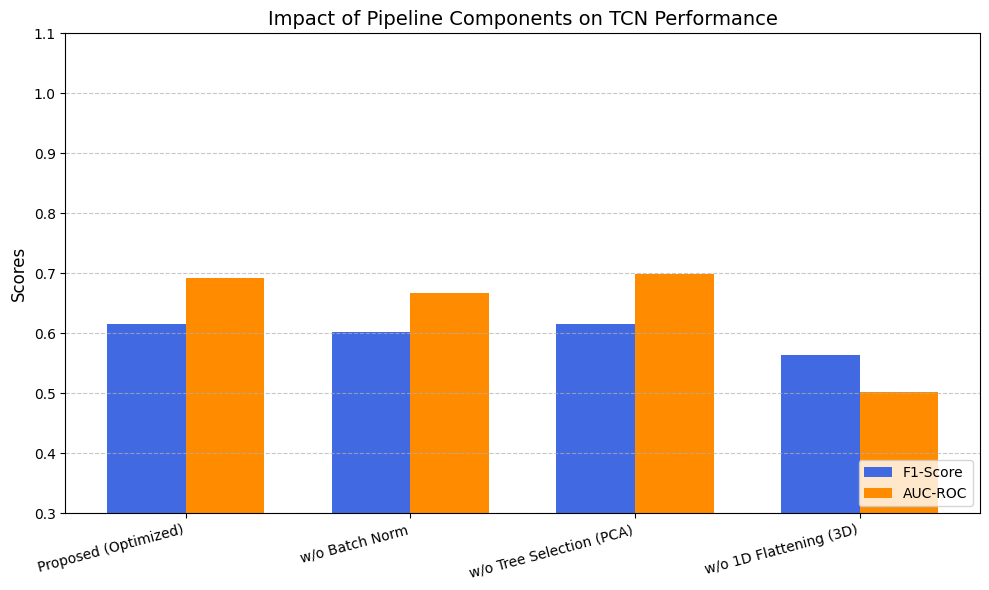

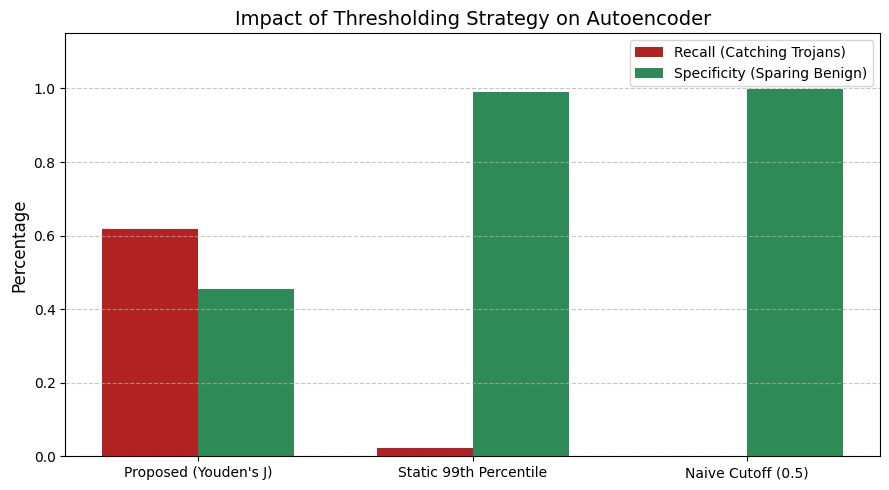

Graphs successfully generated and saved to the 'images/' folder.


In [7]:
import os
import matplotlib.pyplot as plt

# Ensure the images directory exists
os.makedirs('images', exist_ok=True)

# ==========================================
# GRAPH 1: TCN Ablation (F1-Score and AUC)
# ==========================================
# Shortened labels for the x-axis so they fit cleanly
labels_tcn = [
    "Proposed (Optimized)", 
    "w/o Batch Norm", 
    "w/o Tree Selection (PCA)", 
    "w/o 1D Flattening (3D)"
]

# Extract metrics dynamically from our results dictionary
f1_scores = [tcn_results[k]['F1'] for k in tcn_results.keys()]
auc_scores = [tcn_results[k]['AUC'] for k in tcn_results.keys()]

x = np.arange(len(labels_tcn))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, f1_scores, width, label='F1-Score', color='royalblue')
rects2 = ax.bar(x + width/2, auc_scores, width, label='AUC-ROC', color='darkorange')

ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Impact of Pipeline Components on TCN Performance', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels_tcn, rotation=15, ha='right')
ax.set_ylim(0.3, 1.1)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('images/ablation_tcn_graph.png', dpi=300)
plt.show()

# ==========================================
# GRAPH 2: Autoencoder Thresholds (Recall vs Specificity)
# ==========================================
# Shortened labels
labels_ae = [
    "Proposed (Youden's J)", 
    "Static 99th Percentile", 
    "Naive Cutoff (0.5)"
]

# Extract metrics dynamically
recall_scores = [ae_results[k]['Recall'] for k in ae_results.keys()]
spec_scores = [ae_results[k]['Specificity'] for k in ae_results.keys()]

x_ae = np.arange(len(labels_ae))

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x_ae - width/2, recall_scores, width, label='Recall (Catching Trojans)', color='firebrick')
rects2 = ax.bar(x_ae + width/2, spec_scores, width, label='Specificity (Sparing Benign)', color='seagreen')

ax.set_ylabel('Percentage', fontsize=12)
ax.set_title('Impact of Thresholding Strategy on Autoencoder', fontsize=14)
ax.set_xticks(x_ae)
ax.set_xticklabels(labels_ae)
ax.set_ylim(0, 1.15) # Extended slightly so the legend doesn't overlap the bars
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('images/ablation_ae_thresholds.png', dpi=300)
plt.show()

print("Graphs successfully generated and saved to the 'images/' folder.")